<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/CM1_embedding_dimension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


FALSE NEAREST NEIGHBORS

Column 1
tau = 112
Dimension 1: 93.1611%
Dimension 2: 12.2238%
Dimension 3: 0.7347%
Dimension 4: 0.0523%
Dimension 5: 0.0000%
Dimension 6: 0.0000%
Dimension 7: 0.0000%
Dimension 8: 0.0000%
Dimension 9: 0.0000%
Dimension 10: 0.0000%
Selected embedding dimension: 3

Column 2
tau = 69
Dimension 1: 95.0371%
Dimension 2: 46.4300%
Dimension 3: 9.4557%
Dimension 4: 1.3986%
Dimension 5: 0.5593%
Dimension 6: 0.2608%
Dimension 7: 0.1261%
Dimension 8: 0.0212%
Dimension 9: 0.0000%
Dimension 10: 0.0000%
Selected embedding dimension: 5

Column 3
tau = 67
Dimension 1: 96.4573%
Dimension 2: 61.3420%
Dimension 3: 12.6646%
Dimension 4: 1.5208%
Dimension 5: 0.2483%
Dimension 6: 0.1771%
Dimension 7: 0.1679%
Dimension 8: 0.1479%
Dimension 9: 0.1383%
Dimension 10: 0.1072%
Selected embedding dimension: 5

Column 4
tau = 78
Dimension 1: 85.8245%
Dimension 2: 20.5548%
Dimension 3: 1.8738%
Dimension 4: 0.0929%
Dimension 5: 0.0208%
Dimension 6: 0.0210%
Dimension 7: 0.0212%
Dimension 8: 

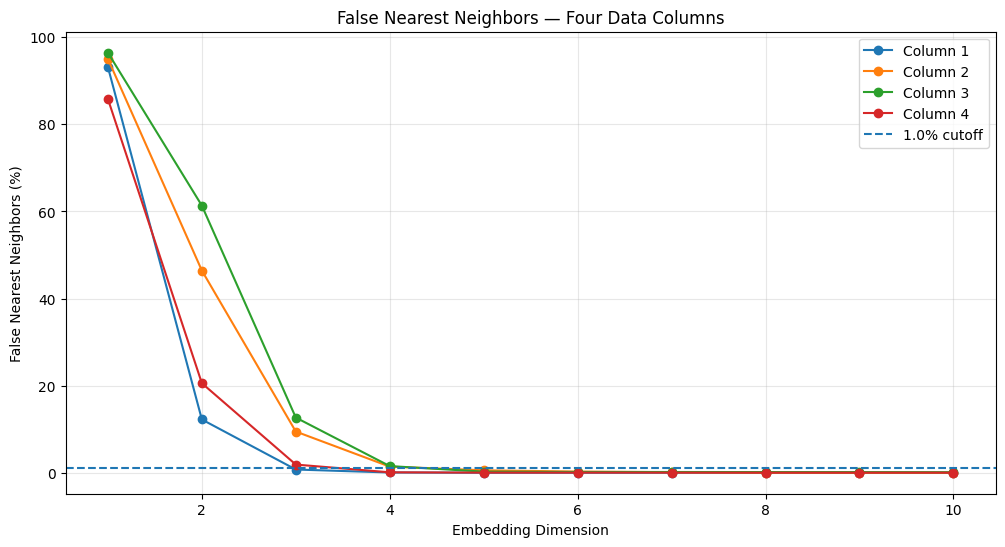


Embedding dimensions:
[3, 5, 5, 4]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO
from sklearn.neighbors import NearestNeighbors


# ============================================================
# 1. LOAD CSV FROM GITHUB
# ============================================================

url = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/CM1_all_vars_30s.csv"

response = requests.get(url)
response.raise_for_status()

raw_text = response.text


# ============================================================
# 2. READ CSV AND IGNORE FIRST LINE
# ============================================================

data_all = np.loadtxt(
    StringIO(raw_text),
    delimiter=",",
    dtype=np.float64,
    skiprows=1
)

data = data_all[:10000]

if data.ndim != 2 or data.shape[1] != 4:
    raise ValueError(
        "Expected exactly four comma-separated numerical columns."
    )


# ============================================================
# 3. SPLIT INTO FOUR ARRAYS
# ============================================================

data1 = data[:, 0]
data2 = data[:, 1]
data3 = data[:, 2]
data4 = data[:, 3]

all_data = [
    data1,
    data2,
    data3,
    data4
]


# ============================================================
# 4. ENTER TAU VALUES FROM AMI
# ============================================================

# Replace these example values with your actual results

tau_by_column = [
    112,
    69,
    67,
    78
]


# ============================================================
# 5. SETTINGS
# ============================================================

max_dimension = 10

R_threshold = 10.0

fnn_cutoff = 1.0


# ============================================================
# 6. DELAY EMBEDDING FUNCTION
# ============================================================

def delay_embed(
    series,
    dimension,
    tau
):

    N = (
        len(series)
        -
        (dimension - 1) * tau
    )

    if N <= 0:

        raise ValueError(
            "Embedding parameters are too large."
        )


    embedded = np.empty(
        (N, dimension)
    )


    for j in range(dimension):

        embedded[:, j] = series[
            j * tau:
            j * tau + N
        ]


    return embedded


# ============================================================
# 7. FALSE NEAREST NEIGHBORS FUNCTION
# ============================================================

def calculate_fnn(
    series,
    tau,
    max_dimension,
    R_threshold
):

    percentages = []


    for m in range(
        1,
        max_dimension + 1
    ):

        N = (
            len(series)
            -
            m * tau
        )

        if N <= 0:
            break


        Xm = delay_embed(
            series,
            m,
            tau
        )[:N]


        Xm1 = delay_embed(
            series,
            m + 1,
            tau
        )[:N]


        neighbors = NearestNeighbors(
            n_neighbors=2
        )

        neighbors.fit(Xm)


        distances, indices = (
            neighbors.kneighbors(Xm)
        )


        nearest_distance = (
            distances[:, 1]
        )

        nearest_index = (
            indices[:, 1]
        )


        extra_difference = np.abs(
            Xm1[:, -1]
            -
            Xm1[
                nearest_index,
                -1
            ]
        )


        valid = (
            nearest_distance
            >
            1e-12
        )


        ratio = np.zeros_like(
            nearest_distance
        )


        ratio[valid] = (
            extra_difference[valid]
            /
            nearest_distance[valid]
        )


        false_neighbors = (
            ratio > R_threshold
        )


        if np.sum(valid) == 0:

            percentage = np.nan

        else:

            percentage = (
                np.sum(
                    false_neighbors[valid]
                )
                /
                np.sum(valid)
            ) * 100


        percentages.append(
            percentage
        )


    return np.asarray(
        percentages
    )


# ============================================================
# 8. RUN FNN ON ALL FOUR COLUMNS
# ============================================================

fnn_by_column = []

m_by_column = []


for column in range(4):

    series = all_data[column]

    tau = tau_by_column[column]


    percentages = calculate_fnn(
        series=series,
        tau=tau,
        max_dimension=max_dimension,
        R_threshold=R_threshold
    )


    fnn_by_column.append(
        percentages
    )


    embedding_dimension = None


    for index, percentage in enumerate(
        percentages
    ):

        dimension = index + 1


        if (
            np.isfinite(percentage)
            and
            percentage < fnn_cutoff
        ):

            embedding_dimension = dimension

            break


    m_by_column.append(
        embedding_dimension
    )


# ============================================================
# 9. PRINT RESULTS
# ============================================================

print("\n======================================")
print("FALSE NEAREST NEIGHBORS")
print("======================================")


for column in range(4):

    print(
        f"\nColumn {column + 1}"
    )

    print(
        f"tau = {tau_by_column[column]}"
    )


    percentages = (
        fnn_by_column[column]
    )


    for i, percentage in enumerate(
        percentages
    ):

        print(
            f"Dimension {i + 1}: "
            f"{percentage:.4f}%"
        )


    print(
        "Selected embedding dimension:",
        m_by_column[column]
    )


# ============================================================
# 10. PLOT ALL FOUR FNN CURVES
# ============================================================

plt.figure(
    figsize=(12, 6)
)


for column in range(4):

    percentages = fnn_by_column[column]

    dimensions = np.arange(
        1,
        len(percentages) + 1
    )


    plt.plot(
        dimensions,
        percentages,
        marker="o",
        label=f"Column {column + 1}"
    )


plt.axhline(
    fnn_cutoff,
    linestyle="--",
    label=f"{fnn_cutoff}% cutoff"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "False Nearest Neighbors (%)"
)

plt.title(
    "False Nearest Neighbors — Four Data Columns"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()


# ============================================================
# 11. FINAL EMBEDDING DIMENSIONS
# ============================================================

print("\nEmbedding dimensions:")
print(m_by_column)